In [19]:
from sklearn.linear_model import Lasso, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd

In [4]:
insurance_data = pd.read_csv("insurance.csv")

X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)

X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [12]:
# Lasso-regression
aphas =[0.001, 0.01, 0.5, 1, 2, 5, 10, 20, 40, 100]
mses = []
for a in aphas:
    lasso_model = Lasso(alpha = a)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    print(f"mse for apha={a} is {mse}")
    mses.append(mse)

mse for apha=0.001 is 20922599.87103596
mse for apha=0.01 is 20922527.32662988
mse for apha=0.5 is 20918648.889825605
mse for apha=1 is 20914832.63508914
mse for apha=2 is 20908106.77995452
mse for apha=5 is 20890881.000633497
mse for apha=10 is 20872844.794796687
mse for apha=20 is 20877828.532378826
mse for apha=40 is 21046489.29389078
mse for apha=100 is 22423172.686023246


<Axes: >

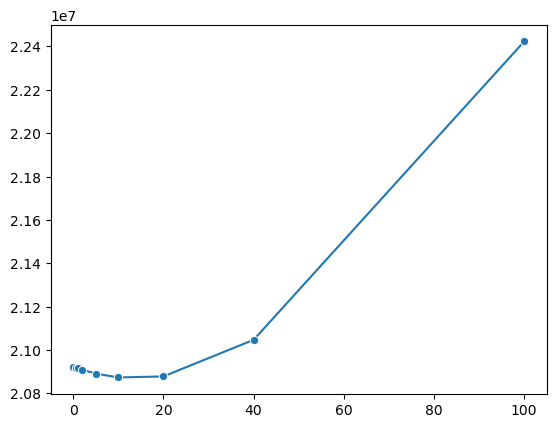

In [13]:
# For understanding
import seaborn as sns
sns.lineplot(x=aphas, y=mses, marker = "o")

In [17]:
# Actual way
a =[0.001, 0.01, 0.5, 1, 2, 5, 10, 20, 40, 100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    random_state = 42)
lasso_cv_model.fit(X_train, y_train)
print("Best alpha: ", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Lasso_cv mse: ", mse)
print("Lasso_cv r2: ", r2)

Best alpha:  0.001
Lasso_cv mse:  20922599.87103596
Lasso_cv r2:  0.8652317499151699


In [24]:
# Same for ridge regularization
a =[0.001, 0.01, 0.5, 1, 2, 5, 10, 20, 40, 100]

ridge_cv_model = RidgeCV(
    alphas = a,
    cv = 5)
ridge_cv_model.fit(X_train, y_train)
print("Best alpha: ", ridge_cv_model.alpha_)

y_pred = ridge_cv_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("ridge_cv mse: ", mse)
print("ridge_cv r2: ", r2)

Best alpha:  0.01
ridge_cv mse:  20920713.858871836
ridge_cv r2:  0.8652438982409308
